사용 장치: cpu
전체 학습 데이터: 60000
테스트 데이터: 10000
학습 데이터: 54000
검증 데이터: 6000
MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=1600, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch 1/20 | loss: 0.2822 | accuracy: 0.9132 | val_loss: 0.0867 | val_accuracy: 0.9758
  -> Best model 저장: saved_models/mnist_cnn_model_20260824_091203.pth
Epoch 2/20 | loss: 0.0918 | accuracy: 0.9719 | val_loss: 0.0558 | val_accuracy: 0.9832
  -> Best model 저장: saved_models/mnist_cnn_model_20260824_091203.pth
Epoch 

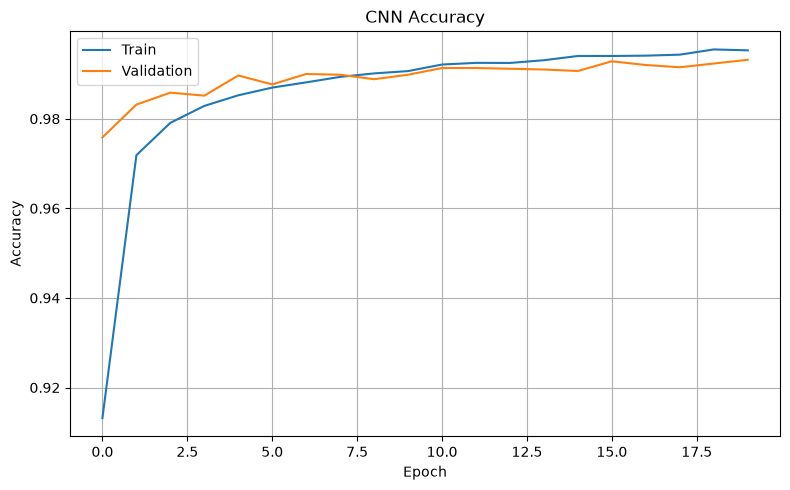

In [3]:
# train_mnist_cnn.py
# ============================================================
# MNIST CNN 분류 모델 - PyTorch 버전
# ============================================================

import os
import json
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
import torchvision.transforms.v2 as transform

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 실행 장치 설정
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 2. 이미지 전처리
# ------------------------------------------------------------
# MNIST 이미지는 28x28 크기의 흑백 이미지이다.
# ToImage()       : PIL/배열을 torchvision Image로 변환한다.
# ToDtype()       : uint8 [0~255]를 float32 [0~1]로 변환한다.
# Normalize()     : CNN 학습을 안정화한다.
mnist_transform = transform.Compose([
    transform.ToImage(),
    transform.ToDtype(torch.float32, scale=True),
])


# ------------------------------------------------------------
# 3. MNIST 데이터셋 다운로드 및 로딩
# ------------------------------------------------------------
data_dir = "./data"

train_full = datasets.MNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=mnist_transform
)

test_dataset = datasets.MNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=mnist_transform
)

print("전체 학습 데이터:", len(train_full))
print("테스트 데이터:", len(test_dataset))


# ------------------------------------------------------------
# 4. Train / Validation 분할
# ------------------------------------------------------------
train_size = int(len(train_full) * 0.9)
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("학습 데이터:", len(train_dataset))
print("검증 데이터:", len(val_dataset))


# ------------------------------------------------------------
# 5. DataLoader
# ------------------------------------------------------------
# Windows + VS Code Jupyter 환경의 multiprocessing 문제를
# 피하기 위해 num_workers=0으로 설정한다.
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ------------------------------------------------------------
# 6. CNN 모델 정의
# ------------------------------------------------------------
class MNISTCNN(nn.Module):
    """
    MNIST 28x28 흑백 이미지를 0~9 숫자로 분류하는 CNN이다.

    입력
        [Batch, 1, 28, 28]

    Conv2d(1 -> 32)
        ↓
    MaxPool
        ↓
    Conv2d(32 -> 64)
        ↓
    MaxPool
        ↓
    Flatten
        ↓
    Dropout
        ↓
    Linear(3136 -> 128)
        ↓
    Linear(128 -> 10)

    마지막 출력은 Softmax가 아닌 10개의 Logit이다.
    CrossEntropyLoss가 내부적으로 Softmax 계열 계산을 처리한다.
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 1채널 흑백 이미지 → 32개 특징맵
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=0
            ),
            nn.ReLU(),

            # 28x28 → 26x26 → 13x13
            nn.MaxPool2d(kernel_size=2),

            # 32개 특징맵 → 64개 특징맵
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=0
            ),
            nn.ReLU(),

            # 13x13 → 11x11 → 5x5
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            # 64 * 5 * 5 = 1600
            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),

            # 10개 숫자 클래스에 대한 Logit 출력
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MNISTCNN().to(device)

print(model)


# ------------------------------------------------------------
# 7. Loss Function / Optimizer
# ------------------------------------------------------------
# MNIST는 0~9의 다중 클래스 분류 문제이다.
# PyTorch의 CrossEntropyLoss는 정수형 class label을 직접 사용한다.
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# ------------------------------------------------------------
# 8. 학습 및 검증 함수
# ------------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


# ------------------------------------------------------------
# 9. 모델 저장 경로
# ------------------------------------------------------------
os.makedirs("saved_models", exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_path = (
    f"saved_models/"
    f"mnist_cnn_model_{timestamp}.pth"
)

log_path = "saved_models/training_log.json"


# ------------------------------------------------------------
# 10. CNN 학습
# ------------------------------------------------------------
num_epochs = 20
patience = 5

best_val_accuracy = -1.0
patience_count = 0

history = {
    "accuracy": [],
    "val_accuracy": [],
    "loss": [],
    "val_loss": []
}

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"loss: {train_loss:.4f} | "
        f"accuracy: {train_accuracy:.4f} | "
        f"val_loss: {val_loss:.4f} | "
        f"val_accuracy: {val_accuracy:.4f}"
    )

    # --------------------------------------------------------
    # 가장 좋은 Validation Accuracy 모델 저장
    # --------------------------------------------------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        patience_count = 0

        torch.save(
            model.state_dict(),
            model_path
        )

        print(
            f"  -> Best model 저장: {model_path}"
        )

    else:
        patience_count += 1

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------
    if patience_count >= patience:
        print("Early Stopping 실행")
        break


# ------------------------------------------------------------
# 11. 학습 로그 저장
# ------------------------------------------------------------
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)


# ------------------------------------------------------------
# 12. Best Model 다시 로드
# ------------------------------------------------------------
model.load_state_dict(
    torch.load(
        model_path,
        map_location=device,
        weights_only=True
    )
)

print("==== history =====")
print(history)
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"모델 저장 완료: {model_path}")


# ------------------------------------------------------------
# 13. 학습 과정 시각화
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    history["accuracy"],
    label="Train"
)

plt.plot(
    history["val_accuracy"],
    label="Validation"
)

plt.legend()
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

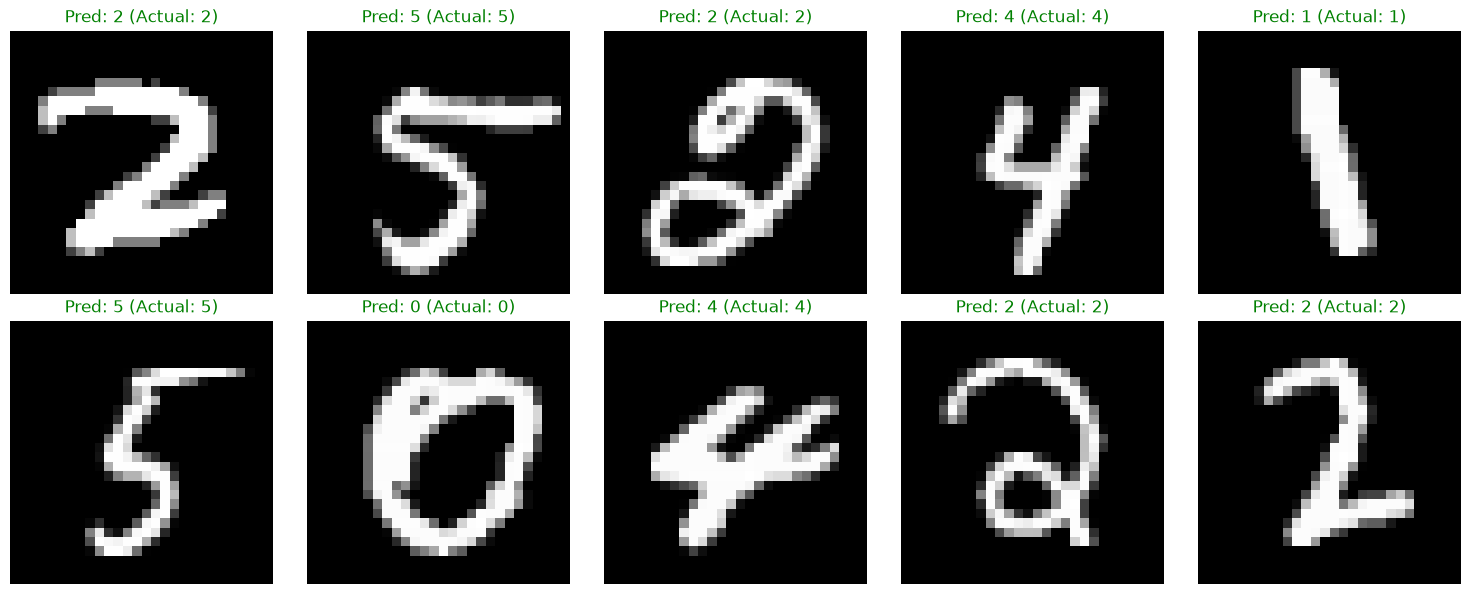

In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. 데이터 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=True)  # 무작위로 추출하기 위해 shuffle=True

# 2. 저장된 모델과 키 구조가 일치하는 CNN 클래스
class MNISTCNN(nn.Module):
    def __init__(self):
        super(MNISTCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(1600, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 3. 장치 설정 및 모델 가중치 로드
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTCNN().to(device)
model_path = 'saved_models/mnist_cnn_model_20260824_091203.pth'

checkpoint = torch.load(model_path, map_location=device)
if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
elif isinstance(checkpoint, dict) and not isinstance(checkpoint, nn.Module):
    model.load_state_dict(checkpoint)
else:
    model = checkpoint

model.eval()

# 4. 테스트 데이터 추출 및 예측 수행
images, labels = next(iter(test_loader))
images_dev, labels_dev = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    _, preds = torch.max(outputs, 1)

# 5. 화면에 숫자 이미지 및 예측 결과 시각화 (10개 표시)
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Normalize 해제 및 이미지 변환 ([1, 28, 28] -> [28, 28])
    img = images[i].numpy().squeeze()
    img = img * 0.3081 + 0.1307  # 역정규화
    
    plt.imshow(img, cmap='gray')
    
    actual = labels[i].item()
    predicted = preds[i].item()
    
    # 정답 여부에 따라 텍스트 색상 변경 (정답: 초록색, 오답: 빨간색)
    color = 'green' if actual == predicted else 'red'
    plt.title(f"Pred: {predicted} (Actual: {actual})", color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
%%writefile requirements.txt
torch
torchvision
streamlit
streamlit-drawable-canvas
numpy
matplotlib
pillow
scipy
scikit-image
opencv-python-headless

Writing requirements.txt


In [6]:
%%writefile streamlit_cnn_app.py
# ============================================================
# MNIST 테스트 샘플 예측 - PyTorch 버전
# ============================================================

import os
import json

import numpy as np
import matplotlib.pyplot as plt
import streamlit as st

import torch
import torch.nn as nn
from torchvision import datasets
import torchvision.transforms.v2 as transform


# ------------------------------------------------------------
# 기본 설정
# ------------------------------------------------------------
MODEL_DIR = "saved_models"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# CNN 모델
# ------------------------------------------------------------
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ------------------------------------------------------------
# 최신 PyTorch 모델 찾기
# ------------------------------------------------------------
def get_latest_model():
    if not os.path.exists(MODEL_DIR):
        return None

    models = [
        f for f in os.listdir(MODEL_DIR)
        if f.endswith(".pth")
    ]

    if not models:
        return None

    models.sort(reverse=True)

    return os.path.join(
        MODEL_DIR,
        models[0]
    )


# ------------------------------------------------------------
# 학습 로그 로드
# ------------------------------------------------------------
def load_training_log(
    log_path="saved_models/training_log.json"
):
    if not os.path.exists(log_path):
        return None

    try:
        with open(
            log_path,
            "r",
            encoding="utf-8"
        ) as f:
            return json.load(f)

    except (json.JSONDecodeError, OSError):
        return None


# ------------------------------------------------------------
# 학습 로그 시각화
# ------------------------------------------------------------
def plot_training_log(log_data):

    st.subheader("학습 로그 (Accuracy / Loss)")

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(10, 4)
    )

    ax[0].plot(
        log_data["accuracy"],
        label="Train Acc"
    )

    ax[0].plot(
        log_data["val_accuracy"],
        label="Val Acc"
    )

    ax[0].set_title("Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(
        log_data["loss"],
        label="Train Loss"
    )

    ax[1].plot(
        log_data["val_loss"],
        label="Val Loss"
    )

    ax[1].set_title("Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()
    ax[1].grid(True)

    st.pyplot(fig)


# ------------------------------------------------------------
# 모델 로드
# ------------------------------------------------------------
def load_model():

    model_path = get_latest_model()

    if model_path is None:
        return None, None

    model = MNISTCNN().to(DEVICE)

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=DEVICE,
            weights_only=True
        )
    )

    model.eval()

    return model, model_path


model, latest_model_path = load_model()


# ------------------------------------------------------------
# MNIST 테스트 데이터
# ------------------------------------------------------------
mnist_transform = transform.Compose([
    transform.ToImage(),
    transform.ToDtype(
        torch.float32,
        scale=True
    )
])

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)


# ------------------------------------------------------------
# Streamlit UI
# ------------------------------------------------------------
st.set_page_config(
    page_title="MNIST Test Sample Prediction",
    layout="centered"
)

st.title("CNN 숫자 예측기 (MNIST 샘플 선택)")

st.markdown(
    "`X_test`의 실제 손글씨 샘플을 선택하여 "
    "PyTorch CNN 모델이 예측합니다."
)


# ------------------------------------------------------------
# 학습 로그
# ------------------------------------------------------------
log_data = load_training_log()

if log_data:
    plot_training_log(log_data)
else:
    st.info(
        "학습 로그 파일이 없거나 비어 있습니다."
    )


# ------------------------------------------------------------
# 테스트 샘플 선택 및 예측
# ------------------------------------------------------------
if model is not None:

    st.markdown("### 테스트 샘플 선택")

    sample_index = st.slider(
        "샘플 인덱스 선택",
        min_value=0,
        max_value=len(test_dataset) - 1,
        value=0
    )

    image, label = test_dataset[sample_index]

    st.image(
        image.squeeze(0).numpy(),
        caption=f"실제 숫자: {label}",
        width=150
    )

    # --------------------------------------------------------
    # 예측
    # --------------------------------------------------------
    with torch.no_grad():

        output = model(
            image.unsqueeze(0).to(DEVICE)
        )

        probability = torch.softmax(
            output,
            dim=1
        )[0]

        pred_class = int(
            probability.argmax().item()
        )

    st.subheader(
        f"예측된 숫자: **{pred_class}**"
    )

    st.bar_chart(
        probability.cpu().numpy()
    )

else:

    st.warning(
        "PyTorch 모델(.pth)이 없습니다. "
        "먼저 학습을 완료해주세요."
    )


Writing streamlit_cnn_app.py


In [7]:
%%writefile streamlit_cnn_hand_app.py
# ============================================================
# 직접 그린 숫자 예측 - PyTorch 버전
# ============================================================

import os

import streamlit as st
from streamlit_drawable_canvas import st_canvas

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

from scipy.ndimage import center_of_mass, shift

import cv2

import torch
import torch.nn as nn


# ------------------------------------------------------------
# 모델 설정
# ------------------------------------------------------------
MODEL_DIR = "saved_models"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# CNN 모델
# ------------------------------------------------------------
class MNISTCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ------------------------------------------------------------
# 최신 모델 찾기
# ------------------------------------------------------------
def get_latest_model():

    if not os.path.exists(MODEL_DIR):
        return None

    models = [
        f for f in os.listdir(MODEL_DIR)
        if f.endswith(".pth")
    ]

    if not models:
        return None

    models.sort(reverse=True)

    return os.path.join(
        MODEL_DIR,
        models[0]
    )


# ------------------------------------------------------------
# 모델 로드
# ------------------------------------------------------------
model_path = get_latest_model()

model = None

if model_path:

    model = MNISTCNN().to(DEVICE)

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=DEVICE,
            weights_only=True
        )
    )

    model.eval()


# ------------------------------------------------------------
# Streamlit UI
# ------------------------------------------------------------
st.set_page_config(
    page_title="MNIST 직접 입력",
    layout="centered"
)

st.title(
    "CNN 숫자 예측기 (MNIST) - PyTorch"
)

st.markdown(
    "검은 배경에 흰색으로 숫자를 그린 후 "
    "CNN 모델의 예측 결과를 확인합니다."
)


# ------------------------------------------------------------
# Canvas
# ------------------------------------------------------------
canvas_result = st_canvas(
    fill_color="#000000",
    stroke_width=30,
    stroke_color="#FFFFFF",
    background_color="#000000",
    width=280,
    height=280,
    drawing_mode="freedraw",
    key="canvas"
)


# ------------------------------------------------------------
# 이미지 전처리
# ------------------------------------------------------------
@st.cache_data
def apply_preprocessing(image_arr):

    results = {}

    # 0~255 범위로 정규화
    norm_img = cv2.normalize(
        image_arr,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype("uint8")

    methods = {

        "Adaptive Gaussian":
            cv2.adaptiveThreshold(
                norm_img,
                255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY,
                11,
                2
            ),

        "Otsu":
            cv2.threshold(
                norm_img,
                0,
                255,
                cv2.THRESH_BINARY,
                cv2.THRESH_OTSU
            )[1],

        "Manual 100":
            np.where(
                norm_img > 100,
                255,
                0
            ).astype("uint8")
    }

    for key, img in methods.items():

        # 이미지 중심 계산
        if np.sum(img > 0) == 0:
            continue

        cy, cx = center_of_mass(img)

        shift_y = int(
            round(img.shape[0] // 2 - cy)
        )

        shift_x = int(
            round(img.shape[1] // 2 - cx)
        )

        shifted = shift(
            img,
            shift=(shift_y, shift_x),
            mode="constant",
            cval=0
        )

        # 28x28로 변경
        resized = cv2.resize(
            shifted.astype("uint8"),
            (28, 28),
            interpolation=cv2.INTER_AREA
        )

        # 0~1 정규화
        norm = (
            resized.astype("float32") / 255.0
        )

        # PyTorch CNN 입력 형태:
        # [Batch, Channel, Height, Width]
        tensor = torch.from_numpy(
            norm
        ).unsqueeze(0).unsqueeze(0)

        results[key] = {
            "processed": resized,
            "tensor": tensor
        }

    return results


# ------------------------------------------------------------
# 예측 함수
# ------------------------------------------------------------
def predict_tensor(tensor):

    tensor = tensor.to(DEVICE)

    with torch.no_grad():

        output = model(tensor)

        probability = torch.softmax(
            output,
            dim=1
        )[0]

        prediction = int(
            probability.argmax().item()
        )

        confidence = float(
            probability.max().item()
        )

    return prediction, confidence, probability.cpu().numpy()


# ------------------------------------------------------------
# 예측 실행
# ------------------------------------------------------------
if (
    st.button("예측 실행")
    and canvas_result.image_data is not None
    and model is not None
):

    img = canvas_result.image_data[:, :, 0]

    img = Image.fromarray(
        img.astype("uint8")
    ).convert("L")

    img = img.resize((28, 28))

    arr = np.array(img)

    # 입력 이미지 저장
    save_path = os.path.join(
        MODEL_DIR,
        "last_input.png"
    )

    img.save(save_path)

    st.info(
        f"입력 이미지를 저장했습니다: {save_path}"
    )

    # --------------------------------------------------------
    # 입력 히트맵
    # --------------------------------------------------------
    st.subheader("입력 히트맵")

    fig, ax = plt.subplots()

    ax.imshow(
        arr,
        cmap="hot"
    )

    ax.axis("off")

    st.pyplot(fig)

    # --------------------------------------------------------
    # 다중 전처리
    # --------------------------------------------------------
    results = apply_preprocessing(arr)

    if not results:

        st.error(
            "숫자 영역을 찾지 못했습니다."
        )

    else:

        prediction_results = {}

        for method, data in results.items():

            pred, confidence, probability = (
                predict_tensor(data["tensor"])
            )

            prediction_results[method] = {
                "processed": data["processed"],
                "prediction": pred,
                "confidence": confidence,
                "prob": probability
            }

        # 가장 높은 confidence를 가진 결과 선택
        best_method, best = max(
            prediction_results.items(),
            key=lambda x: x[1]["confidence"]
        )

        st.subheader(
            f"최종 예측: **{best['prediction']}** "
            f"(신뢰도: {best['confidence']:.2f})"
        )

        st.caption(
            f"선택된 전처리: {best_method}"
        )

        st.bar_chart(
            best["prob"]
        )

        # ----------------------------------------------------
        # 전처리별 결과
        # ----------------------------------------------------
        st.subheader(
            "다중 전처리 예측 결과"
        )

        for method, data in prediction_results.items():

            st.markdown(
                f"### {method} "
                f"(예측: {data['prediction']}, "
                f"신뢰도: {data['confidence']:.2f})"
            )

            st.image(
                data["processed"],
                width=140
            )

elif model is None:

    st.warning(
        "PyTorch 모델(.pth)이 없습니다. "
        "먼저 CNN 모델을 학습해주세요."
    )


Writing streamlit_cnn_hand_app.py


In [8]:
%%writefile streamlit_cnn_webcam_app.py
# ============================================================
# 웹캠 숫자 인식기 - PyTorch 버전
# ============================================================

import os

import streamlit as st

import numpy as np
import cv2

from PIL import Image, ImageOps

from scipy.ndimage import center_of_mass, shift

import torch
import torch.nn as nn


# ------------------------------------------------------------
# 모델 설정
# ------------------------------------------------------------
MODEL_DIR = "saved_models"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# CNN 모델
# ------------------------------------------------------------
class MNISTCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ------------------------------------------------------------
# 최신 모델 찾기
# ------------------------------------------------------------
def get_latest_model():

    if not os.path.exists(MODEL_DIR):
        return None

    models = [
        f for f in os.listdir(MODEL_DIR)
        if f.endswith(".pth")
    ]

    if not models:
        return None

    models.sort(reverse=True)

    return os.path.join(
        MODEL_DIR,
        models[0]
    )


# ------------------------------------------------------------
# 모델 로드
# ------------------------------------------------------------
model_path = get_latest_model()

model = None

if model_path:

    model = MNISTCNN().to(DEVICE)

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=DEVICE,
            weights_only=True
        )
    )

    model.eval()


# ------------------------------------------------------------
# 전처리
# ------------------------------------------------------------
def preprocess_image(image_arr):

    # --------------------------------------------------------
    # RGB → Grayscale인 경우 그대로 사용
    # --------------------------------------------------------
    gray = image_arr

    # 대비 강화
    norm = cv2.normalize(
        gray,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype("uint8")

    # Gaussian Blur
    blurred = cv2.GaussianBlur(
        norm,
        (5, 5),
        0
    )

    # 흰 종이 + 검정 펜
    # MNIST는 검정 배경 + 흰색 숫자이므로 반전한다.
    inverted = cv2.bitwise_not(
        blurred
    )

    # Otsu 이진화
    _, binary = cv2.threshold(
        inverted,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 숫자가 없는 경우
    if np.sum(binary > 0) < 20:
        return None

    # 중심 계산
    cy, cx = center_of_mass(binary)

    shift_y = int(
        round(binary.shape[0] // 2 - cy)
    )

    shift_x = int(
        round(binary.shape[1] // 2 - cx)
    )

    shifted = shift(
        binary,
        shift=(shift_y, shift_x),
        mode="constant",
        cval=0
    )

    # 28x28
    resized = cv2.resize(
        shifted.astype("uint8"),
        (28, 28),
        interpolation=cv2.INTER_AREA
    )

    # 0~1
    input_arr = (
        resized.astype("float32") / 255.0
    )

    # PyTorch:
    # [Batch, Channel, Height, Width]
    tensor = torch.from_numpy(
        input_arr
    ).unsqueeze(0).unsqueeze(0)

    return resized, tensor


# ------------------------------------------------------------
# 예측
# ------------------------------------------------------------
def predict(tensor):

    tensor = tensor.to(DEVICE)

    with torch.no_grad():

        output = model(tensor)

        probability = torch.softmax(
            output,
            dim=1
        )[0]

        pred_class = int(
            probability.argmax().item()
        )

    return (
        pred_class,
        probability.cpu().numpy()
    )


# ------------------------------------------------------------
# Streamlit UI
# ------------------------------------------------------------
st.set_page_config(
    page_title="웹캠 숫자 인식기",
    layout="centered"
)

st.title(
    "웹캠 숫자 인식기 (MNIST + PyTorch)"
)

st.markdown(
    "흰 종이에 검은색 펜으로 0~9 숫자를 "
    "작성한 후 웹캠으로 촬영합니다."
)


if model is None:

    st.warning(
        "PyTorch 모델(.pth)이 없습니다. "
        "먼저 모델을 학습해주세요."
    )

else:

    image_data = st.camera_input(
        "숫자가 보이도록 웹캠으로 촬영"
    )

    if image_data is not None:

        image = Image.open(
            image_data
        ).convert("RGB")

        st.image(
            image,
            caption="입력 이미지",
            width=500
        )

        # RGB → Grayscale
        gray = ImageOps.grayscale(
            image
        )

        gray_np = np.array(gray)

        processed = preprocess_image(
            gray_np
        )

        if processed is None:

            st.error(
                "숫자 영역을 찾지 못했습니다."
            )

        else:

            resized, tensor = processed

            pred_class, probability = (
                predict(tensor)
            )

            # ----------------------------------------------
            # 예측 결과
            # ----------------------------------------------
            st.subheader(
                f"예측된 숫자: **{pred_class}**"
            )

            st.bar_chart(
                probability
            )

            # ----------------------------------------------
            # 전처리 이미지
            # ----------------------------------------------
            st.subheader(
                "전처리된 MNIST 입력 이미지"
            )

            st.image(
                resized,
                width=150,
                clamp=True
            )


Writing streamlit_cnn_webcam_app.py


In [10]:
%%writefile streamlit_cnn_webcam_app.py
# ============================================================
# 웹캠 숫자 인식기 - PyTorch (Canny Edge + 정밀 윤곽선 추출)
# ============================================================

import os
import streamlit as st
import numpy as np
import cv2
from PIL import Image, ImageOps
import torch
import torch.nn as nn

# ------------------------------------------------------------
# 모델 설정 및 정의
# ------------------------------------------------------------
MODEL_DIR = "saved_models"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def get_latest_model():
    if not os.path.exists(MODEL_DIR):
        return None
    models = [f for f in os.listdir(MODEL_DIR) if f.endswith(".pth")]
    if not models:
        return None
    models.sort(reverse=True)
    return os.path.join(MODEL_DIR, models[0])

# 모델 로드
model_path = get_latest_model()
model = None

if model_path:
    model = MNISTCNN().to(DEVICE)
    model.load_state_dict(
        torch.load(model_path, map_location=DEVICE, weights_only=True)
    )
    model.eval()

# ------------------------------------------------------------
# 정밀 전처리 (Canny Edge + 엣지 팽창 + 노이즈 제거)
# ------------------------------------------------------------
def preprocess_image(gray_arr):
    h_orig, w_orig = gray_arr.shape

    # 1. 외곽 8% 마진 마스킹
    margin_h = int(h_orig * 0.08)
    margin_w = int(w_orig * 0.08)
    
    # 2. 가우시안 블러로 종이 질감/접힘선 평탄화
    blurred = cv2.GaussianBlur(gray_arr, (7, 7), 0)

    # 3. Canny Edge 추출 (펜 선의 경계선만 선명히 검출)
    edges = cv2.Canny(blurred, 50, 150)

    # 마진 테두리 강제 제거
    edges[:margin_h, :] = 0
    edges[-margin_h:, :] = 0
    edges[:, :margin_w] = 0
    edges[:, -margin_w:] = 0

    # 4. Dilate를 적용하여 Canny 엣지의 틈을 채우고 굵게 만듦
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    binary = cv2.dilate(edges, kernel, iterations=2)

    # 5. 윤곽선 탐지
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, binary

    # 6. 진짜 숫자 윤곽선 선별 (상단/하단 종이 구김선 제외)
    valid_contours = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = cv2.contourArea(c)
        aspect_ratio = w / float(h)
        
        # 선 형태나 너무 얇거나 가로로 긴 구김선(aspect_ratio > 3.0) 제외
        if area > 150 and w > 12 and h > 20 and aspect_ratio < 2.5:
            valid_contours.append(c)

    if not valid_contours:
        return None, None, binary

    # 가장 큰 숫자 윤곽선 선택
    c = max(valid_contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # 7. 숫자 영역 Crop
    digit_crop = binary[y:y+h, x:x+w]

    # 8. 비율 유지 리사이즈 (20x20 크기)
    if h > w:
        new_h = 20
        new_w = max(1, int(round(w * (20.0 / h))))
    else:
        new_w = 20
        new_h = max(1, int(round(h * (20.0 / w))))

    resized_digit = cv2.resize(digit_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # 9. 28x28 캔버스 패딩
    padded_28x28 = np.zeros((28, 28), dtype=np.uint8)
    start_y = (28 - new_h) // 2
    start_x = (28 - new_w) // 2
    padded_28x28[start_y:start_y+new_h, start_x:start_x+new_w] = resized_digit

    # 10. MNIST Normalization
    input_arr = padded_28x28.astype("float32") / 255.0
    normalized_arr = (input_arr - 0.1307) / 0.3081

    tensor = torch.from_numpy(normalized_arr).unsqueeze(0).unsqueeze(0)

    return padded_28x28, tensor, binary

# ------------------------------------------------------------
# 예측
# ------------------------------------------------------------
def predict(tensor):
    tensor = tensor.to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
        probability = torch.softmax(output, dim=1)[0]
        pred_class = int(probability.argmax().item())
    return pred_class, probability.cpu().numpy()

# ------------------------------------------------------------
# Streamlit UI
# ------------------------------------------------------------
st.set_page_config(page_title="웹캠 숫자 인식기", layout="centered")
st.title("웹캠 숫자 인식기 (MNIST + PyTorch)")

if model is None:
    st.warning("PyTorch 모델(.pth)이 없습니다. 먼저 모델을 학습해주세요.")
else:
    image_data = st.camera_input("숫자가 잘 보이도록 촬영하세요")

    if image_data is not None:
        image = Image.open(image_data).convert("RGB")
        gray_np = np.array(ImageOps.grayscale(image))

        padded_28x28, tensor, debug_binary = preprocess_image(gray_np)

        col1, col2 = st.columns(2)
        with col1:
            st.image(image, caption="원본 촬영 이미지", use_container_width=True)

        if padded_28x28 is None:
            st.error("숫자를 찾지 못했습니다. 종이를 펼치고 펜을 약간 더 굵게 써주세요.")
            st.image(debug_binary, caption="전처리 마스크", width=200)
        else:
            pred_class, probability = predict(tensor)

            with col2:
                st.image(padded_28x28, caption="28x28 최종 입력 결과", width=160)

            st.subheader(f"예측된 숫자: **{pred_class}**")
            st.bar_chart(probability)

Overwriting streamlit_cnn_webcam_app.py
